In [1]:
library(tidyverse)
library(dplyr)
library(ggplot2)
library(bedr)
library(readr)
library(glue)
library(ACAT)
library(data.table)
library(qvalue)

Warning message:
"'timedatectl' indicates the non-existent timezone name 'n/a'"
unable to deduce timezone name from 'America/Chicago'

-- Attaching packages ------------------------------------------------------------------------------------------------------------------------------------------------------ tidyverse 1.3.1 --

v ggplot2 3.5.1     v purrr   1.0.2
v tibble  3.2.1     v dplyr   1.1.4
v tidyr   1.3.1     v stringr 1.5.1
v readr   1.4.0     v forcats 0.5.1

-- Conflicts --------------------------------------------------------------------------------------------------------------------------------------------------------- tidyverse_conflicts() --
x dplyr::filter() masks stats::filter()
x dplyr::lag()    masks stats::lag()



######################
#### bedr v1.0.7 ####
######################

checking binary availability...
  * Checking path for bedtools... PASS
    /scratch/midway3/cnajar/anaconda3/envs/leafcutter2/bin/bedtools
  * Checking path for bedops... FAIL
  * Checki

In [2]:
GTEx_pvals <- read.table('GTEx_cluster.psi_pvals.txt.gz', sep='\t', header=TRUE)

In [3]:
GTEx_pvals %>% na.omit() %>% head()

,intron,cluster,itype,ctype,gene_name,gene_id,Adipose.Subcutaneous_v_Artery.Tibial,Adipose.Subcutaneous_v_Brain.FrontalCortex_BA9,Adipose.Subcutaneous_v_Brain.Hippocampus,Adipose.Subcutaneous_v_Breast.MammaryTissue,⋯,WholeBlood_v_Brain.Hippocampus,WholeBlood_v_Breast.MammaryTissue,WholeBlood_v_Cells.EBV.transformedlymphocytes,WholeBlood_v_Colon.Sigmoid,WholeBlood_v_Colon.Transverse,WholeBlood_v_Liver,WholeBlood_v_Muscle.Skeletal,WholeBlood_v_Nerve.Tibial,WholeBlood_v_Skin.NotSunExposed_Suprapubic,WholeBlood_v_Skin.SunExposed_Lowerleg
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,chr10:134786:179993:clu_22961_+,chr10:clu_22961_+,PR,PR,ZMYND11,ENSG00000015171.19,6.389023e-01,6.405439e-28,8.399826e-21,0.5058285819,⋯,0.000496901,0.5375327,2.505877e-06,0.1744157,0.6047880179,4.967093e-03,2.028193e-08,2.990387e-01,0.0003781644,0.0004593439
3,chr10:210048:218454:clu_22963_+,chr10:clu_22963_+,PR,PR,ZMYND11,ENSG00000015171.19,1.965324e-13,9.022247e-05,2.039272e-05,0.0008219554,⋯,0.083899479,0.2444704,2.641317e-13,0.0286682,0.0004218138,7.707575e-09,2.237016e-05,2.902560e-01,0.0914981469,0.3071532673
4,chr10:236915:237584:clu_22964_+,chr10:clu_22964_+,PR,PR,ZMYND11,ENSG00000015171.19,3.679149e-08,1.109410e-01,3.594815e-02,0.0001142234,⋯,0.000874089,0.4973815,8.848680e-02,0.8074223,0.9051685816,5.892780e-01,1.877814e-12,2.972643e-09,0.5592737185,0.4334837606
5,chr10:239525:240055:clu_22965_+,chr10:clu_22965_+,PR,PR,ZMYND11,ENSG00000015171.19,5.735250e-01,9.323497e-02,9.180700e-01,0.6921983137,⋯,0.470549690,0.4146809,5.463432e-01,0.4160666,0.4238094403,3.672616e-01,5.950911e-01,3.826044e-01,0.6523562616,0.5804591900
6,chr10:240111:240892:clu_22966_+,chr10:clu_22966_+,PR,PR,ZMYND11,ENSG00000015171.19,2.706570e-01,8.516581e-03,5.386764e-02,0.6543205851,⋯,0.462914863,0.1975525,8.693826e-01,0.5242629,0.7814292190,5.992469e-01,2.944038e-01,4.346495e-01,0.3578686675,0.6624623501
10,chr10:992659:995928:clu_22970_+,chr10:clu_22970_+,PR,PR,GTPBP4,ENSG00000107937.18,7.728914e-01,2.023558e-04,2.808336e-02,0.5721886710,⋯,0.599388704,0.8254812,2.152794e-03,0.3646821,0.5604066712,4.204553e-01,1.819219e-02,7.104545e-01,0.7610027301,0.8455450284


In [4]:
columns_to_keep <- colnames(GTEx_pvals)[
  grepl("Brain-FrontalCortex_BA9", colnames(GTEx_pvals)) | # Keep if it's Brain-FrontalCortex_BA9
  (!grepl("Brain", colnames(GTEx_pvals)) &                 # OR if "Brain" is not in the column name
     !grepl("Brain.*Brain", colnames(GTEx_pvals)))         # AND it doesn't appear twice
]

# # Subset the data frame
# filtered_df <- df[, columns_to_keep, drop = FALSE]

In [5]:
672/10

[1] 67.2

In [6]:
df <- GTEx_pvals[,columns_to_keep]

In [7]:
filtered_df <- df[rowSums(is.na(df)) <= 10, columns_to_keep[7:672]] 
filtered_df[is.na(filtered_df)] <- 0.99
filtered_df[filtered_df >= 0.99999] <- 0.99999
filtered_df[filtered_df <= 1e-300] <- 0.99

In [8]:
filtered_df %>% head()

,Adipose.Subcutaneous_v_Artery.Tibial,Adipose.Subcutaneous_v_Breast.MammaryTissue,Adipose.Subcutaneous_v_Cells.EBV.transformedlymphocytes,Adipose.Subcutaneous_v_Colon.Sigmoid,Adipose.Subcutaneous_v_Liver,Adipose.Subcutaneous_v_Nerve.Tibial,Adipose.Visceral_Omentum_v_Adipose.Subcutaneous,Adipose.Visceral_Omentum_v_Artery.Tibial,Adipose.Visceral_Omentum_v_Breast.MammaryTissue,Adipose.Visceral_Omentum_v_Cells.EBV.transformedlymphocytes,⋯,WholeBlood_v_Artery.Tibial,WholeBlood_v_Breast.MammaryTissue,WholeBlood_v_Cells.EBV.transformedlymphocytes,WholeBlood_v_Colon.Sigmoid,WholeBlood_v_Colon.Transverse,WholeBlood_v_Liver,WholeBlood_v_Muscle.Skeletal,WholeBlood_v_Nerve.Tibial,WholeBlood_v_Skin.NotSunExposed_Suprapubic,WholeBlood_v_Skin.SunExposed_Lowerleg
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,6.389023e-01,0.5058285819,5.352464e-30,3.702968e-01,6.482002e-06,2.332641e-03,6.105433e-02,0.2146306,0.5438133335,4.345074e-23,⋯,0.30312742,0.5375327,2.505877e-06,0.1744157,0.6047880179,4.967093e-03,2.028193e-08,2.990387e-01,0.0003781644,0.0004593439
3,1.965324e-13,0.0008219554,1.022046e-47,7.061643e-11,2.311283e-30,7.916194e-01,2.838675e-15,0.7030399,0.0005470484,7.917784e-18,⋯,0.01154752,0.2444704,2.641317e-13,0.0286682,0.0004218138,7.707575e-09,2.237016e-05,2.902560e-01,0.0914981469,0.3071532673
4,3.679149e-08,0.0001142234,2.034304e-22,8.861809e-12,2.852726e-04,3.545079e-17,1.728854e-09,0.3243761,0.0507372088,2.937411e-05,⋯,0.77162825,0.4973815,8.848680e-02,0.8074223,0.9051685816,5.892780e-01,1.877814e-12,2.972643e-09,0.5592737185,0.4334837606
5,5.735250e-01,0.6921983137,9.036040e-01,7.154354e-01,6.118452e-01,7.009319e-01,6.404540e-01,0.2828455,0.9075146604,5.862783e-01,⋯,0.61185418,0.4146809,5.463432e-01,0.4160666,0.4238094403,3.672616e-01,5.950911e-01,3.826044e-01,0.6523562616,0.5804591900
6,2.706570e-01,0.6543205851,1.242169e-04,8.453052e-03,5.192698e-01,6.185365e-02,2.774091e-02,0.2884803,0.0177851018,1.361204e-01,⋯,0.65654327,0.1975525,8.693826e-01,0.5242629,0.7814292190,5.992469e-01,2.944038e-01,4.346495e-01,0.3578686675,0.6624623501
10,7.728914e-01,0.5721886710,1.557018e-02,2.077019e-02,2.621903e-01,1.091831e-02,1.558121e-01,0.5559726,0.6151399461,1.248828e-05,⋯,0.57395162,0.8254812,2.152794e-03,0.3646821,0.5604066712,4.204553e-01,1.819219e-02,7.104545e-01,0.7610027301,0.8455450284


In [9]:
adj.pvals <- filtered_df %>% t() %>% ACAT()

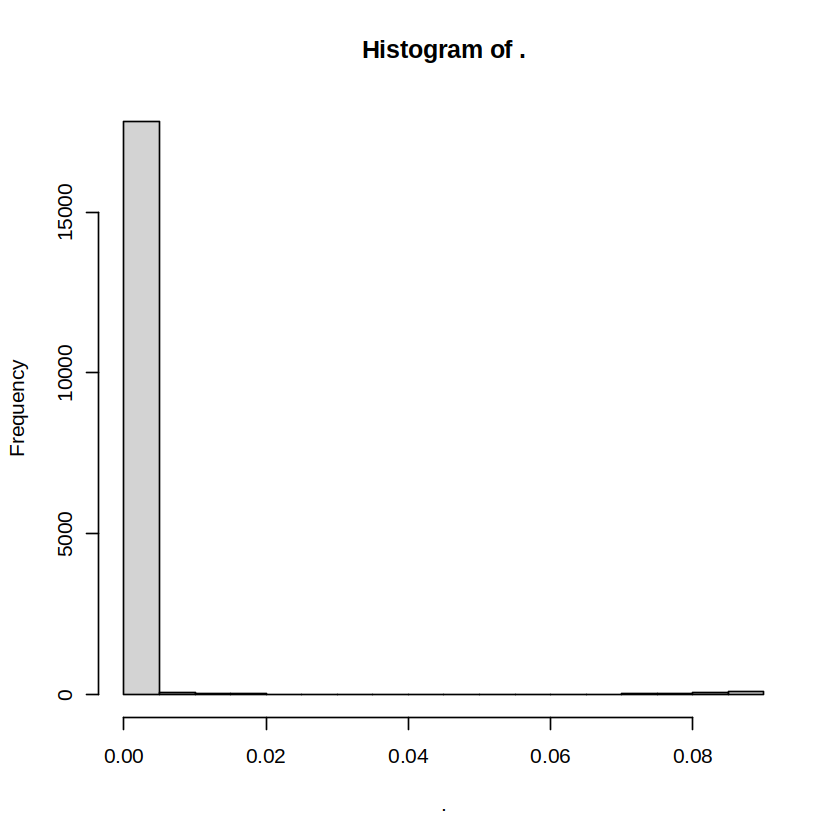

In [10]:
(adj.pvals %>% qvalue())$qvalues %>% hist()

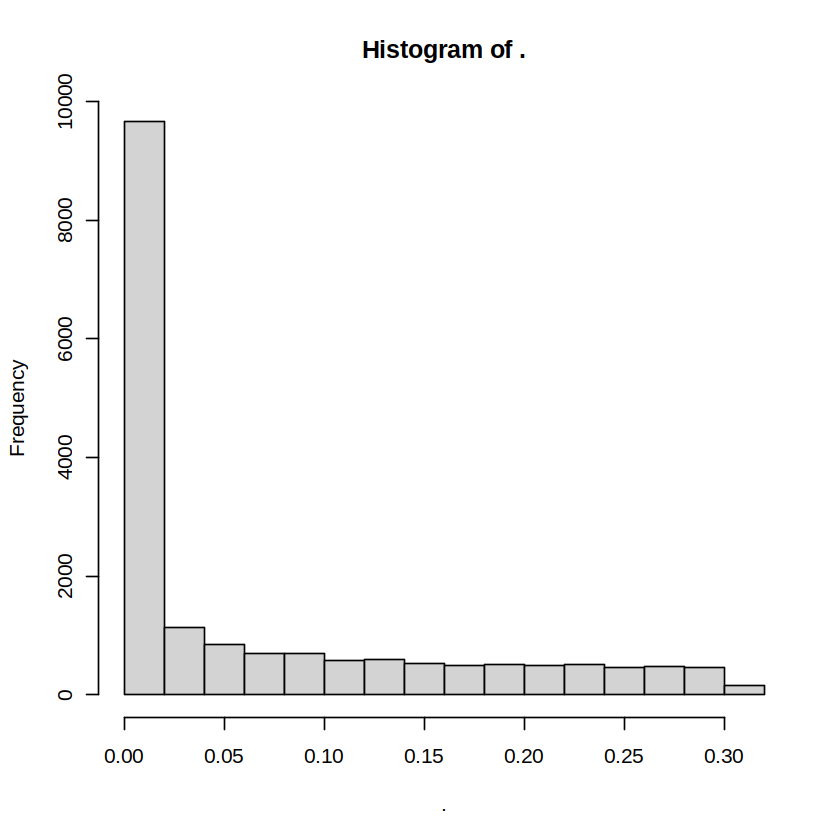

In [11]:
(filtered_df[,1] %>% qvalue())$qvalues %>% hist()

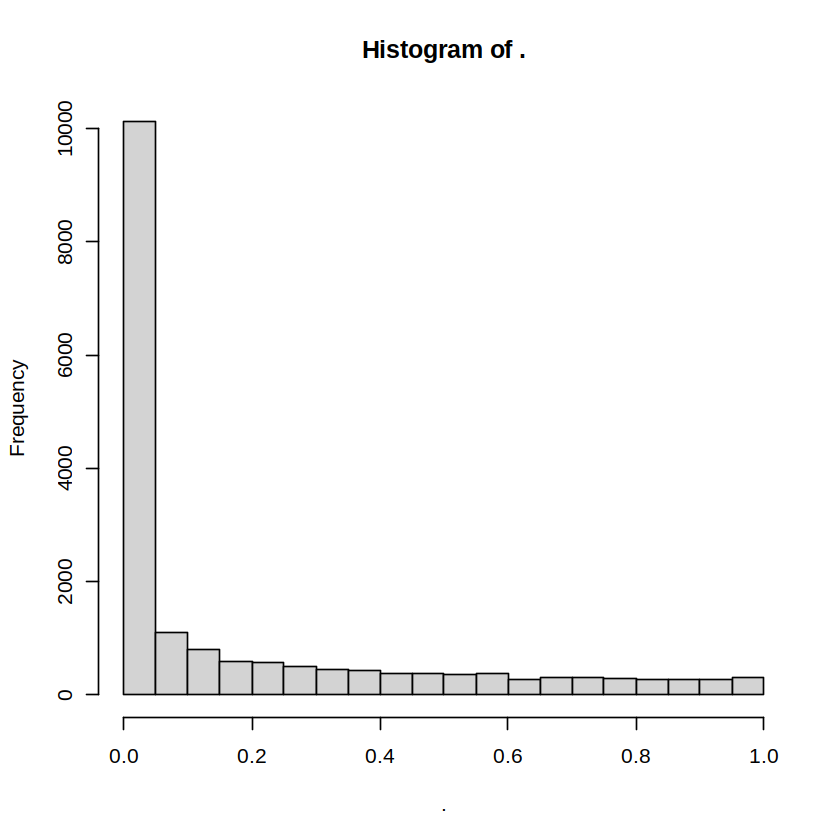

In [12]:
filtered_df[,1] %>% hist()

In [4]:
psi <- read.table('GTEx.psi.tsv.gz', sep='\t', header=TRUE)

ERROR: Error in parse(text = input): <text>:1:5: unexpected '['
1: x = [
        ^


In [14]:
(GTEx_pvals['Bladder_v_Brain.Anteriorcingulatecortex_BA24'] <= 1e-2) %>% na.omit() %>% sum()

[1] 12285

In [17]:
(GTEx_pvals['Bladder_v_Brain.FrontalCortex_BA9'] <= 1e-2) %>% na.omit() %>% sum()

[1] 12803

In [14]:
cluster_pvals <- GTEx_pvals %>%
  group_by(cluster) %>%
  summarize(across(everything(), ~ min(.x, na.rm = TRUE), .names = "min_{.col}"), .groups = "drop")

In [ ]:
cluster_pvals <- GTEx_pvals %>%
  group_by(cluster) %>%
  summarize(across(everything(), min, .names = "min_{.col}"), .groups = "drop")

In [ ]:
rds_file <- 'Adipose-Subcutaneous_v_Cells-EBV-transformedlymphocytes.rds'
rds = readRDS(glue::glue('/project/yangili1/cfbuenabadn/leafcutter2_paper/code/results/ds_v_dge/{rds_file}'))

In [ ]:
counts <- read.table('/project/yangili1/cfbuenabadn/leafcutter2_paper/code/tmp/ds_v_dge/Adipose-Subcutaneous_v_Cells-EBV-transformedlymphocytes.cluster_counts_per_tissue.tsv.gz', sep='\t', header=TRUE)
colnames(counts) <- gsub("\\.", "-", colnames(counts))
colnames(counts) <- c(colnames(counts)[1:6], paste(colnames(counts)[-6:-1], 'counts', sep='.'))

In [ ]:
ds <- merge(rds$ds, counts, by = c('intron', 'cluster', 'itype', 'ctype', 'gene_name', 'gene_id'))

In [ ]:
ds <- merge(rds$ds, counts, by = c('intron', 'cluster', 'itype', 'ctype', 'gene_name', 'gene_id'))
sig_clusters <- ds %>% filter(abs(deltapsi) >= 0.1, p.adjust <= 5e-2) %>% pull(cluster) %>% unique() 

In [ ]:
ds %>% filter(cluster %in% sig_clusters) %>% 
    select(c('cluster', 'Adipose-Subcutaneous.counts', 'Cells-EBV-transformedlymphocytes.counts')) %>%
    aggregate(. ~ cluster, data = ., sum) %>% head()

In [ ]:
ds %>% filter(cluster == 'chr10:clu_23098_+')

In [5]:
comparisons <- sub("\\.rds$", "", list.files('/project/yangili1/cfbuenabadn/leafcutter2_paper/code/results/ds_v_dge/'))

In [14]:
get_sig_clusters <- function(comparison) {
    path_dir <- '/project/yangili1/cfbuenabadn/leafcutter2_paper/code/results/ds_v_dge/'
    rds = readRDS(glue::glue(path_dir, '{comparison}.rds'))
    sig_clusters <- rds$ds %>% filter(abs(deltapsi) >= 0.1, p.adjust <= 5e-2, itype=='UP') %>% pull(cluster) %>% unique() 
    return(sig_clusters)
}

get_sig_clusters2 <- function(comparison) {
    path_dir <- '/project/yangili1/cfbuenabadn/leafcutter2_paper/code/results/ds_v_dge/'
    rds = readRDS(glue::glue(path_dir, '{comparison}.rds'))
    sig_genes <- rds$dge %>% filter(padj <= 5e-2, abs(log2FoldChange) >= 1) %>% pull(gene_id) %>% unique()
    sig_clusters <- rds$ds %>% filter(abs(deltapsi) >= 0.1, p.adjust <= 5e-2, itype=='UP', ctype=='PR,UP',
                                 (gene_id %in% sig_genes)) %>% pull(cluster) %>% unique()
    return(sig_clusters)
}


In [15]:
comparison <- comparisons[1]
sig1 <- get_sig_clusters(comparison)
sig2 <- get_sig_clusters2(comparison)
# path_dir <- '/project/yangili1/cfbuenabadn/leafcutter2_paper/code/results/ds_v_dge/'
# rds = readRDS(glue::glue(path_dir, '{comparison}.rds'))

In [16]:
sig1 %>% length()

[1] 204

In [17]:
sig2 %>% length()

[1] 51

In [17]:
cluster_list <- c()
cluster_all <- c()
pb = txtProgressBar(min = 0, max = length(comparisons), initial = 0) 
stepi <- 0
for (comparison in comparisons) {
    sig_clusters <- get_sig_clusters(comparison)
    cluster_list <- union(cluster_list, sig_clusters)
    cluster_all <- c(cluster_all, sig_clusters)
    setTxtProgressBar(pb,stepi)
    stepi <- stepi + 1
}
close(pb)

In [18]:
cluster_list %>% length()

[1] 4414

In [19]:
ds_df <- cluster_all %>% table() %>% as.data.frame()
colnames(ds_df) <- c('cluster', 'freq')

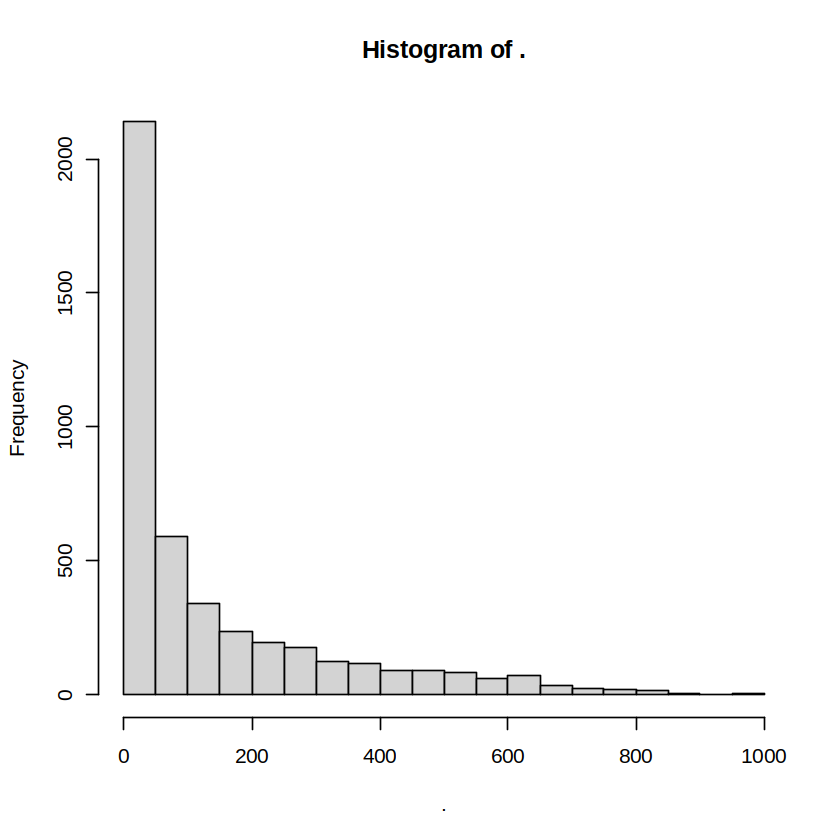

In [20]:
ds_df %>% pull(freq) %>% hist()

In [21]:
psi <- read.table('GTEx.psi.tsv.gz', sep='\t', header=TRUE)
counts <- read.table('GTEx.cluster_counts.tsv.gz', sep='\t', header=TRUE)

In [22]:
psi %>% dim()

[1] 154681     56

In [23]:
psi %>% head()

,intron,cluster,itype,ctype,gene_name,gene_id,Artery.Aorta,Brain.Cortex,Brain.Nucleusaccumbens_basalganglia,Esophagus.Muscularis,⋯,Breast.MammaryTissue,Cells.EBV.transformedlymphocytes,Colon.Sigmoid,Colon.Transverse,Liver,Muscle.Skeletal,Nerve.Tibial,Skin.NotSunExposed_Suprapubic,Skin.SunExposed_Lowerleg,WholeBlood
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,chr10:100185637:100185903:clu_24473_-,chr10:clu_24473_-,PR,PR,ERLIN1,ENSG00000107566.13,0.20743759,0.09522813,0.18451222,0.17773963,⋯,0.22171605,0.24637515,0.18616711,0.28007936,0.381063617,0.238700045,0.22108737,0.32213425,0.33280560,0.45946279
2,chr10:100185637:100185961:clu_24473_-,chr10:clu_24473_-,PR,PR,ERLIN1,ENSG00000107566.13,0.79256241,0.90477187,0.81548778,0.82226037,⋯,0.77828395,0.75362485,0.81383289,0.71992064,0.618936383,0.761299955,0.77891263,0.67786575,0.66719440,0.54053721
3,chr10:100190968:100192458:clu_24474_-,chr10:clu_24474_-,UP,"PR,UP",CHUK,ENSG00000213341.10,0.08303895,0.24072157,0.15767497,0.08753754,⋯,0.12851371,0.02517681,0.11978424,0.06349370,0.030676155,0.209774067,0.20899864,0.15886844,0.16586070,0.04232702
4,chr10:100190968:100193297:clu_24474_-,chr10:clu_24474_-,PR,"PR,UP",CHUK,ENSG00000213341.10,0.89816188,0.74664335,0.83234193,0.89709106,⋯,0.85580729,0.96407765,0.86666230,0.92079227,0.960513086,0.783436936,0.77622460,0.82414870,0.82394228,0.93795909
5,chr10:100190968:100193388:clu_24474_-,chr10:clu_24474_-,UP,"PR,UP",CHUK,ENSG00000213341.10,0.01879917,0.01397441,0.01051475,0.01581324,⋯,0.01567899,0.01074553,0.01397863,0.01571402,0.009786221,0.007654834,0.01477676,0.01751866,0.01052825,0.01971404
6,chr10:100235764:100236849:clu_24475_-,chr10:clu_24475_-,PR,PR,CWF19L1,ENSG00000095485.16,0.47616226,0.48206309,0.47544388,0.47373322,⋯,0.47319545,0.47167302,0.48221108,0.47797789,0.461370483,0.476118293,0.47730936,0.48262216,0.47516178,0.47263617


In [37]:
psi %>% filter(cluster %in% (ds_df %>% pull(cluster)), ctype == 'PR,UP') %>% pull(cluster) %>% unique() %>% length()

[1] 4180

In [67]:
up_psi <- psi %>% filter(cluster %in% (ds_df %>% pull(cluster)), itype == 'UP', ctype == 'PR,UP')
up_psi <- up_psi[rowSums(is.na(up_psi)) <= 10,]

In [68]:
tissues <- (up_psi %>% colnames())[7:56]

In [69]:
X <- up_psi[rowSums(is.na(up_psi)) <= 0, tissues]

In [62]:
X %>% dim()

[1] 4085   50

In [41]:
Y <- t(apply(X, 1, quantile))
colnames(Y) <- c('cero', 'twentyfive', 'fifty', 'seventyfive', 'onehundred')

In [42]:
ds_df %>% arrange(desc(freq))

cluster,freq
<fct>,<int>
chr1:clu_1118_+,968
chr8:clu_19481_+,955
chr22:clu_46057_-,952
chr1:clu_111_+,926
chr17:clu_39003_-,907
chr14:clu_31963_-,879
chr3:clu_10449_-,860
chr1:clu_1195_+,859
chr1:clu_4129_-,855


In [43]:
idx <- Y %>% as.data.frame() %>% filter(onehundred >= 0.75, twentyfive >= 0.25) %>% rownames()

In [44]:
idx

[1] "186"  "237"  "238"  "325"  "441"  "588"  "1171" "1651" "1745" "1754"
[11] "1769" "2135" "2628" "2655" "2717" "3025" "3053" "3057" "3456" "3605"
[21] "3683" "3752" "3780" "4084" "4576" "4989" "5625" "5651" "5663" "5669"
[31] "5877" "6159" "6247" "6687"

In [45]:
genes <- up_psi[rowSums(is.na(up_psi)) <= 0,] %>% pull(gene_id) %>% unique() 

In [46]:
ten_tissues <- c('Brain.Anteriorcingulatecortex_BA24',
 'Brain.Cortex',
 'Brain.FrontalCortex_BA9',
 'Brain.Putamen_basalganglia',
 'Heart.AtrialAppendage',
 'Liver',
 'Lung',
 'Muscle.Skeletal',
 'Skin.NotSunExposed_Suprapubic',
 'WholeBlood')

In [42]:
count_sum_per_cluster <- counts %>% filter(gene_id %in% genes) %>% select(-intron, -itype) %>%
  group_by(cluster, ctype, gene_name, gene_id) %>%
  summarise(across(everything(), sum, .names = "{col}"), .groups = "drop") #%>%
#   select(all_of(ten_tissues))

In [43]:
count_sum_per_cluster$min_tissue <- count_sum_per_cluster %>% select(all_of(ten_tissues)) %>% apply(., 1, min, na.rm = FALSE)

In [44]:
high_quality_clusters <- count_sum_per_cluster %>% filter(min_tissue >= 100, ctype =='PR,UP') %>% pull(cluster)

In [45]:
high_quality_introns <- psi %>% filter(cluster %in% high_quality_clusters, itype=='UP')

In [46]:
Y_ <- high_quality_introns %>% select(all_of(ten_tissues)) %>%  apply(., 1, quantile) %>% t()

colnames(Y_) <- c('cero', 'twentyfive', 'fifty', 'seventyfive', 'onehundred')

In [47]:
high_quality_introns_quant <- cbind(high_quality_introns %>% select(intron, cluster, itype, ctype, gene_name, gene_id), Y_)

In [48]:
high_quality_introns_quant$diff <- high_quality_introns_quant$onehundred - high_quality_introns_quant$cero

In [49]:
high_quality_introns_quant %>% arrange(desc(diff))

intron,cluster,itype,ctype,gene_name,gene_id,cero,twentyfive,fifty,seventyfive,onehundred,diff
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr19:15397855:15398629:clu_42835_-,chr19:clu_42835_-,UP,"PR,UP",AKAP8L,ENSG00000011243.17,0.1028887624,0.1262967517,0.199226429,0.241919230,0.3928126,0.2899238
chr3:186784696:186785882:clu_9368_+,chr3:clu_9368_+,UP,"PR,UP",EIF4A2,ENSG00000156976.16,0.0118528002,0.0455780588,0.073853494,0.162360583,0.2855128,0.2736600
chr6:36600276:36601151:clu_15382_+,chr6:clu_15382_+,UP,"PR,UP",SRSF3,ENSG00000112081.16,0.1503860308,0.1801669163,0.273014924,0.341731995,0.4140208,0.2636348
chr6:36598983:36599820:clu_15382_+,chr6:clu_15382_+,UP,"PR,UP",SRSF3,ENSG00000112081.16,0.1175386351,0.1522090017,0.242104412,0.275908483,0.3692218,0.2516831
chr17:81511803:81511902:clu_39791_-,chr17:clu_39791_-,UP,"PR,UP",ACTG1,ENSG00000184009.9,0.0017515419,0.0046464155,0.004935047,0.006988902,0.2479222,0.2461707
chr7:151079922:151080436:clu_19384_-,chr7:clu_19384_-,UP,"PR,UP",FASTK,ENSG00000164896.19,0.0226632900,0.0237059838,0.037886063,0.064566919,0.2311253,0.2084620
chr1:33024567:33031543:clu_2898_-,chr1:clu_2898_-,UP,"PR,UP",AK2,ENSG00000004455.16,0.0246086223,0.0487394841,0.101048374,0.185206042,0.2258692,0.2012606
chr3:186787882:186788309:clu_9370_+,chr3:clu_9370_+,UP,"PR,UP",EIF4A2,ENSG00000156976.16,0.0107306485,0.0135175841,0.069896717,0.145362136,0.2101555,0.1994249
chr2:38749346:38749528:clu_6707_-,chr2:clu_6707_-,UP,"PR,UP",SRSF7,ENSG00000115875.18,0.1599221187,0.2106017855,0.277584825,0.301840860,0.3564102,0.1964880


In [50]:
psi %>% filter(cluster == 'chr6:clu_15382_+')

intron,cluster,itype,ctype,gene_name,gene_id,Artery.Aorta,Brain.Cortex,Brain.Nucleusaccumbens_basalganglia,Esophagus.Muscularis,⋯,Breast.MammaryTissue,Cells.EBV.transformedlymphocytes,Colon.Sigmoid,Colon.Transverse,Liver,Muscle.Skeletal,Nerve.Tibial,Skin.NotSunExposed_Suprapubic,Skin.SunExposed_Lowerleg,WholeBlood
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr6:36598983:36599820:clu_15382_+,chr6:clu_15382_+,UP,"PR,UP",SRSF3,ENSG00000112081.16,0.2421237,0.1553675,0.1452475,0.2372866,⋯,0.3029237,0.06017274,0.2669667,0.2053891,0.2241360,0.2694572,0.3472978,0.2600728,0.2846198,0.3692218
chr6:36598983:36601151:clu_15382_+,chr6:clu_15382_+,PR,"PR,UP",SRSF3,ENSG00000112081.16,0.4727442,0.6652602,0.6835711,0.4878169,⋯,0.3515309,0.86512452,0.4202142,0.5422594,0.5140945,0.4394463,0.2778293,0.3801562,0.3282480,0.2167574
chr6:36600276:36601151:clu_15382_+,chr6:clu_15382_+,UP,"PR,UP",SRSF3,ENSG00000112081.16,0.2851321,0.1793723,0.1711814,0.2748965,⋯,0.3455454,0.07470274,0.3128192,0.2523514,0.2617695,0.2910965,0.3748729,0.3597710,0.3871322,0.4140208


In [52]:
# chr6:36597983-36602151

In [53]:
idx_clu <- up_psi[idx,] %>% pull(cluster)

In [54]:
ds_df %>% filter(cluster %in% idx_clu) %>% arrange(desc(freq))

cluster,freq
<fct>,<int>
chr8:clu_19481_+,955
chr22:clu_46057_-,952
chr1:clu_111_+,926
chr16:clu_34730_+,845
chr8:clu_19930_+,822
chr12:clu_29945_-,821
chr6:clu_15296_+,815
chr4:clu_12010_-,804
chr10:clu_23495_+,783


In [48]:
X %>% dim()

[1] 3650   50

In [55]:
up_psi[rowSums(is.na(up_psi)) <= 0,]$intron

[1] "chr10:100190968:100192458:clu_24474_-"
   [2] "chr10:100190968:100193388:clu_24474_-"
   [3] "chr10:100498207:100499159:clu_24487_-"
   [4] "chr10:100499598:100500109:clu_24489_-"
   [5] "chr10:100500159:100501653:clu_24489_-"
   [6] "chr10:100500159:100502253:clu_24489_-"
   [7] "chr10:100501710:100502253:clu_24489_-"
   [8] "chr10:100508048:100508460:clu_24491_-"
   [9] "chr10:100509102:100516095:clu_24492_-"
  [10] "chr10:101782597:101783272:clu_24507_-"
  [11] "chr10:101792943:101797979:clu_24509_-"
  [12] "chr10:101793744:101797979:clu_24509_-"
  [13] "chr10:101828696:101828818:clu_24514_-"
  [14] "chr10:102727157:102727674:clu_23619_+"
  [15] "chr10:102727791:102728430:clu_23619_+"
  [16] "chr10:102728529:102729722:clu_23620_+"
  [17] "chr10:102729808:102732858:clu_23620_+"
  [18] "chr10:103100019:103100662:clu_24532_-"
  [19] "chr10:103100019:103100751:clu_24532_-"
  [20] "chr10:103100943:103101044:clu_24532_-"
  [21] "chr10:103105801:103111744:clu_24534_-"
  [22] "chr10:103106706:103111744:clu_24534_-"
  [23] "chr10:103111805:103139405:clu_24534_-"
  [24] "chr10:103139479:103140116:clu_24534_-"
  [25] "chr10:103398528:103399646:clu_23624_+"
  [26] "chr10:103399830:103400396:clu_23624_+"
  [27] "chr10:110300736:110303467:clu_24569_-"
  [28] "chr10:112433281:112433540:clu_24581_-"
  [29] "chr10:112447467:112448381:clu_23657_+"
  [30] "chr10:112447467:112448881:clu_23657_+"
  [31] "chr10:112448489:112448881:clu_23657_+"
  [32] "chr10:11257872:11270665:clu_23019_+"  
  [33] "chr10:113719643:113721031:clu_23669_+"
  [34] "chr10:114130669:114131146:clu_24587_-"
  [35] "chr10:117285471:117285693:clu_24606_-"
  [36] "chr10:117285799:117290185:clu_24606_-"
  [37] "chr10:118691403:118693701:clu_24614_-"
  [38] "chr10:118693749:118695140:clu_24614_-"
  [39] "chr10:119576905:119577079:clu_24623_-"
  [40] "chr10:119580538:119581921:clu_24624_-"
  [41] "chr10:119580846:119581921:clu_24624_-"
  [42] "chr10:119892945:119898243:clu_23716_+"
  [43] "chr10:120866764:120871169:clu_23725_+"
  [44] "chr10:120880562:120880825:clu_23726_+"
  [45] "chr10:120890009:120900028:clu_23728_+"
  [46] "chr10:12136170:12142432:clu_23028_+"  
  [47] "chr10:12142565:12143116:clu_23028_+"  
  [48] "chr10:12149961:12156906:clu_23029_+"  
  [49] "chr10:12162289:12167752:clu_23030_+"  
  [50] "chr10:12179132:12180394:clu_23905_-"  
  [51] "chr10:12180489:12184888:clu_23905_-"  
  [52] "chr10:121974081:121974305:clu_24640_-"
  [53] "chr10:121974081:121974389:clu_24640_-"
  [54] "chr10:122932661:122933373:clu_24644_-"
  [55] "chr10:124774782:124789038:clu_24658_-"
  [56] "chr10:124994606:124997963:clu_24659_-"
  [57] "chr10:125730399:125731864:clu_23771_+"
  [58] "chr10:125731925:125733403:clu_23771_+"
  [59] "chr10:125741201:125742219:clu_23773_+"
  [60] "chr10:130068608:130079565:clu_24689_-"
  [61] "chr10:130079901:130101093:clu_24690_-"
  [62] "chr10:130104230:130110703:clu_24690_-"
  [63] "chr10:131901330:131911561:clu_23795_+"
  [64] "chr10:131912598:131934457:clu_23795_+"
  [65] "chr10:131934555:131934893:clu_23796_+"
  [66] "chr10:131935006:131940030:clu_23796_+"
  [67] "chr10:132337421:132337564:clu_23804_+"
  [68] "chr10:132337695:132344497:clu_23805_+"
  [69] "chr10:132365550:132366298:clu_23808_+"
  [70] "chr10:132365550:132366434:clu_23808_+"
  [71] "chr10:132365550:132366614:clu_23808_+"
  [72] "chr10:132365550:132366845:clu_23808_+"
  [73] "chr10:13684864:13693481:clu_23917_-"  
  [74] "chr10:14935564:14939809:clu_23927_-"  
  [75] "chr10:14945189:14945434:clu_23929_-"  
  [76] "chr10:14945189:14947524:clu_23929_-"  
  [77] "chr10:14945189:14953901:clu_23929_-"  
  [78] "chr10:14945565:14949035:clu_23929_-"  
  [79] "chr10:14947609:14949035:clu_23929_-"  
  [80] "chr10:15103683:15109701:clu_23931_-"  
  [81] "chr10:15106698:15109701:clu_23931_-"  
  [82] "chr10:17152099:17153506:clu_23940_-"  
  [83] "chr10:17168917:17169309:clu_23941_-"  
  [84] "chr10:17169539:17174550:clu_23941_-"  
  [85] "chr10:17172024:17174550:clu_23941_-"  
  [86] "

In [112]:
X <- up_psi[rowSums(is.na(up_psi)) <= 0, tissues]
rownames(X) <- up_psi[rowSums(is.na(up_psi)) <= 0,]$intron

In [50]:
psi %>% filter(cluster == 'chr8:clu_19481_+')

intron,cluster,itype,ctype,gene_name,gene_id,Artery.Aorta,Brain.Cortex,Brain.Nucleusaccumbens_basalganglia,Esophagus.Muscularis,⋯,Breast.MammaryTissue,Cells.EBV.transformedlymphocytes,Colon.Sigmoid,Colon.Transverse,Liver,Muscle.Skeletal,Nerve.Tibial,Skin.NotSunExposed_Suprapubic,Skin.SunExposed_Lowerleg,WholeBlood
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr8:2124217:2129126:clu_19481_+,chr8:clu_19481_+,PR,"PR,UP",MYOM2,ENSG00000036448.9,0.2622124,0.7661363,0.4755833,0.715257,⋯,0.4879278,0.07232443,0.5535757,0.4994778,0.3742208,0.993753184,0.3427279,0.5071955,0.4813732,0.8652073
chr8:2127881:2129126:clu_19481_+,chr8:clu_19481_+,UP,"PR,UP",MYOM2,ENSG00000036448.9,0.7377876,0.2338637,0.5244167,0.284743,⋯,0.5120722,0.92767557,0.4464243,0.5005222,0.6257792,0.006246816,0.6572721,0.4928045,0.5186268,0.1347927


In [51]:
X

,Artery.Aorta,Brain.Cortex,Brain.Nucleusaccumbens_basalganglia,Esophagus.Muscularis,Adipose.Visceral_Omentum,AdrenalGland,Artery.Coronary,Bladder,Brain.Amygdala,Brain.Anteriorcingulatecortex_BA24,⋯,Breast.MammaryTissue,Cells.EBV.transformedlymphocytes,Colon.Sigmoid,Colon.Transverse,Liver,Muscle.Skeletal,Nerve.Tibial,Skin.NotSunExposed_Suprapubic,Skin.SunExposed_Lowerleg,WholeBlood
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr10:100190968:100192458:clu_24474_-,0.0830389521,0.2407215680,0.157674975,8.753754e-02,0.0817457972,0.0390286804,1.078209e-01,1.123610e-01,0.1533244101,0.1576481556,⋯,0.1285137126,2.517681e-02,0.119784245,6.349370e-02,0.0306761548,0.2097740673,0.2089986449,0.1588684396,0.1658607010,0.042327018
chr10:100190968:100193388:clu_24474_-,0.0187991722,0.0139744120,0.010514751,1.581324e-02,0.0131517192,0.0087858354,1.706494e-02,1.487181e-02,0.0070337334,0.0149683292,⋯,0.0156789925,1.074553e-02,0.013978630,1.571402e-02,0.0097862207,0.0076548343,0.0147767594,0.0175186627,0.0105282523,0.019714040
chr10:100498207:100499159:clu_24487_-,0.2903566590,0.2475714295,0.240875122,2.417582e-01,0.2519950591,0.2250830481,2.518879e-01,2.057754e-01,0.2336802285,0.2070391569,⋯,0.2742707380,1.805201e-01,0.211172139,1.859468e-01,0.2087604874,0.1129350324,0.3015598773,0.2450514150,0.2907946237,0.174686816
chr10:100499598:100500109:clu_24489_-,0.2925359714,0.1932268198,0.216121672,3.333732e-01,0.3109713445,0.2645810989,3.212605e-01,3.330570e-01,0.2203847746,0.1855458576,⋯,0.2985399353,2.496546e-01,0.340211933,3.210916e-01,0.3289088184,0.2351715535,0.3016240295,0.2774421686,0.2732430602,0.308342210
chr10:100500159:100501653:clu_24489_-,0.0198316885,0.0121058777,0.011414277,2.377158e-02,0.0289272968,0.0166842274,2.344295e-02,1.898552e-02,0.0093393837,0.0030634849,⋯,0.0257052995,2.256364e-02,0.025307736,2.808938e-02,0.0266000721,0.0111821535,0.0200733426,0.0257666916,0.0226865145,0.051886185
chr10:100500159:100502253:clu_24489_-,0.3497426399,0.2080576272,0.236789969,3.657433e-01,0.3130473393,0.2760698203,3.460934e-01,3.842562e-01,0.2466977384,0.2128421836,⋯,0.3100004731,2.806946e-01,0.366285839,3.487636e-01,0.3487910640,0.2634408385,0.3216138856,0.2942987940,0.2883121341,0.306227447
chr10:100501710:100502253:clu_24489_-,0.0209077756,0.0109099374,0.009736987,2.159134e-02,0.0244459336,0.0159135194,2.135289e-02,1.592270e-02,0.0154190154,0.0033987323,⋯,0.0282476053,2.172668e-02,0.021838522,2.633038e-02,0.0239713447,0.0089320810,0.0194965340,0.0198853539,0.0267613337,0.048971140
chr10:100508048:100508460:clu_24491_-,0.0009771331,0.1206386417,0.048819340,3.295422e-04,0.0010148969,0.0060018594,9.180308e-04,1.528974e-03,0.0208581362,0.0715637230,⋯,0.0010270954,2.806301e-06,0.001713852,1.777032e-03,0.0029534724,0.0023957350,0.0023793146,0.0022060527,0.0011308290,0.002844602
chr10:100509102:100516095:clu_24492_-,0.1158654221,0.1143893229,0.056903583,1.435922e-01,0.0732695985,0.0820288252,9.998103e-02,1.226689e-01,0.0429098473,0.0494935974,⋯,0.0556920031,6.986361e-02,0.131731177,1.025500e-01,0.1060005719,0.1089996422,0.0433625046,0.0585394166,0.0506273475,0.055715642


In [52]:
(psi %>% filter(cluster == 'chr8:clu_19481_+'))[,'Brain.Putamen_basalganglia']

[1] 0.3693119 0.6306881

In [ ]:
Brain_Anterior_cingulate_cortex_BA24  Brain_Frontal_Cortex_BA9     Heart_Atrial_Appendage  Lung             Skin_Not_Sun_Exposed_Suprapubic
Brain_Cortex                          Brain_Putamen_basal_ganglia  Liver                   Muscle_Skeletal  Whole_Blood

In [33]:
suppressMessages(library(ComplexHeatmap))
# suppressMessages(library(gprofiler2))

In [70]:
tissue_code = fread("../../splice-pub/analysis/gtex-tissue-code.csv", header = F, col.names = c("tissue", "tissue_code"))

legendBreaks <- seq(-4, 4, 2)
# colors <- rev(RColorBrewer::brewer.pal(length(legendBreaks), "RdBu"))
colors <- c("#053061", "#2166AC", "#F7F7F7", "#B2182B", "#67001F")
colfunc <- circlize::colorRamp2(
  breaks = legendBreaks, 
  colors = colors
  )

cluster_method = "ward.D2"


cluster_method = "ward.D2"

col_labs = left_join(
  x = data.frame(tissue = colnames(X)[-1]),
  y = tissue_code,
  by = "tissue"
) %>%
  pull(tissue_code)



set.seed(123)
ht <- X %>%
#   column_to_rownames("cluster") %>%
  as.matrix %>% t %>% scale %>% t %>%
  Heatmap(
    column_title = glue("Unproductive splicing across GTEx tissues, N = {nrow(X)}"),
    col = colfunc,
    row_km = 12, row_gap = unit(0.2, "mm"), 
    column_km = 3, 
    column_gap = unit(0, "mm"),
    show_parent_dend_line = FALSE,
    show_row_names = FALSE, clustering_method_rows = cluster_method, show_row_dend = F,
    clustering_method_columns = cluster_method, column_dend_height = unit(1.5, "in"), show_column_dend = TRUE,
    heatmap_legend_param = list(title = "PSI (z-score)"),
    use_raster = TRUE, raster_quality = 2#,
#     column_labels = col_labs
    )

'magick' package is suggested to install to give better rasterization.

Set `ht_opt$message = FALSE` to turn off this message.



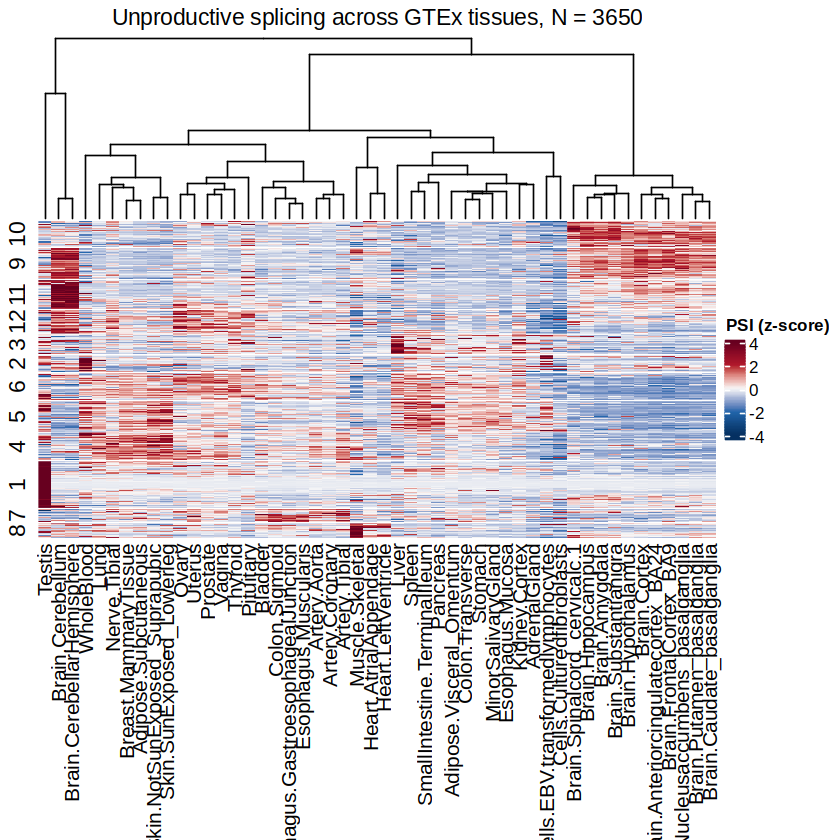

In [71]:
ht

In [74]:
tissue_code = fread("../../splice-pub/analysis/gtex-tissue-code.csv", header = F, col.names = c("tissue", "tissue_code"))

legendBreaks <- seq(-4, 4, 2)
# colors <- rev(RColorBrewer::brewer.pal(length(legendBreaks), "RdBu"))
colors <- c("#053061", "#2166AC", "#F7F7F7", "#B2182B", "#67001F")
colfunc <- circlize::colorRamp2(
  breaks = legendBreaks, 
  colors = colors
  )

cluster_method = "ward.D2"


cluster_method = "ward.D2"

col_labs = left_join(
  x = data.frame(tissue = colnames(X)[-1]),
  y = tissue_code,
  by = "tissue"
) %>%
  pull(tissue_code)



set.seed(123)
ht <- X %>%
#   column_to_rownames("cluster") %>%
  as.matrix %>% t %>% scale %>% t %>%
  Heatmap(
    column_title = glue("Unproductive splicing across GTEx tissues, N = {nrow(X)}"),
    col = colfunc,
    row_km = 6, row_gap = unit(0.5, "mm"), 
    column_km = 3, 
    column_gap = unit(0.5, "mm"),
    show_parent_dend_line = FALSE,
    show_row_names = FALSE, clustering_method_rows = cluster_method, show_row_dend = F,
    clustering_method_columns = cluster_method, column_dend_height = unit(1.5, "in"), show_column_dend = TRUE,
    heatmap_legend_param = list(title = "PSI (z-score)"),
    use_raster = TRUE, raster_quality = 2#,
#     column_labels = col_labs
    )

'magick' package is suggested to install to give better rasterization.

Set `ht_opt$message = FALSE` to turn off this message.



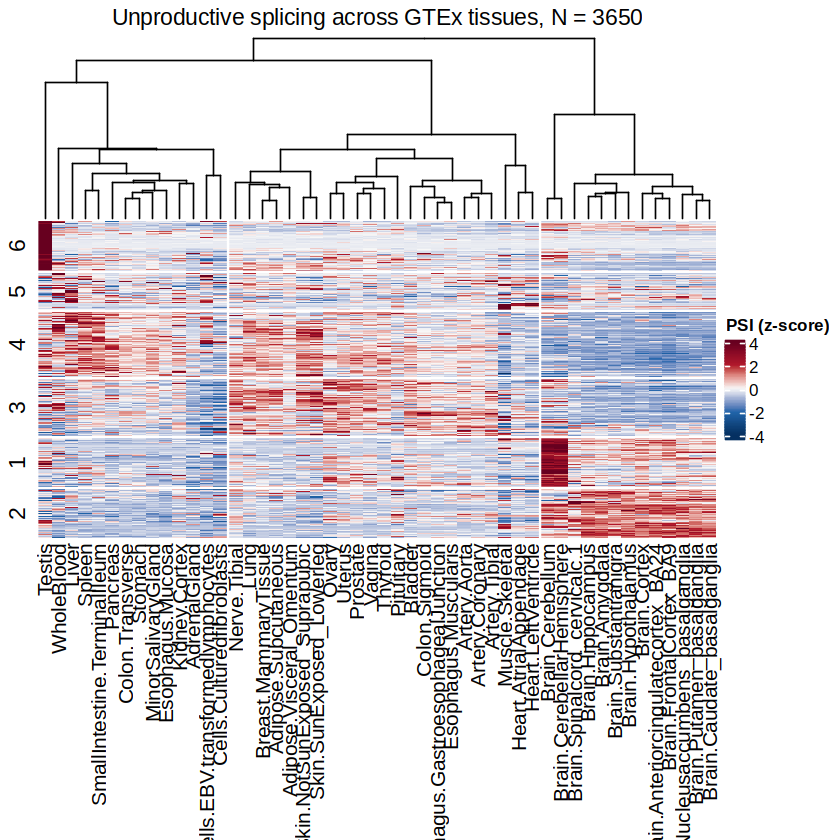

In [75]:
ht

In [98]:
library(ComplexHeatmap)
library(glue)
library(dplyr)

column_colors <- sapply(colnames(X), function(tissue) {
  paste0("#", gtex_colors[[tissue]]$tissue_color_hex)
})

# Create the heatmap
set.seed(123)
ht <- X %>%
  as.matrix() %>% 
  t() %>% 
  scale() %>% 
  t() %>%
  Heatmap(
    column_title = glue("Unproductive splicing across GTEx tissues, N = {nrow(X)}"),
    col = colfunc,  # Example color function
    row_km = 6, row_gap = unit(0.5, "mm"), 
    column_km = 3, 
    column_gap = unit(0.5, "mm"),
    show_parent_dend_line = FALSE,
    show_row_names = FALSE, clustering_method_rows = "complete", show_row_dend = FALSE,
    clustering_method_columns = "complete", column_dend_height = unit(1.5, "in"), show_column_dend = TRUE,
    heatmap_legend_param = list(title = "PSI (z-score)"),
    use_raster = TRUE, raster_quality = 2,
    column_names_gp = gpar(col = column_colors)
  )


'magick' package is suggested to install to give better rasterization.

Set `ht_opt$message = FALSE` to turn off this message.



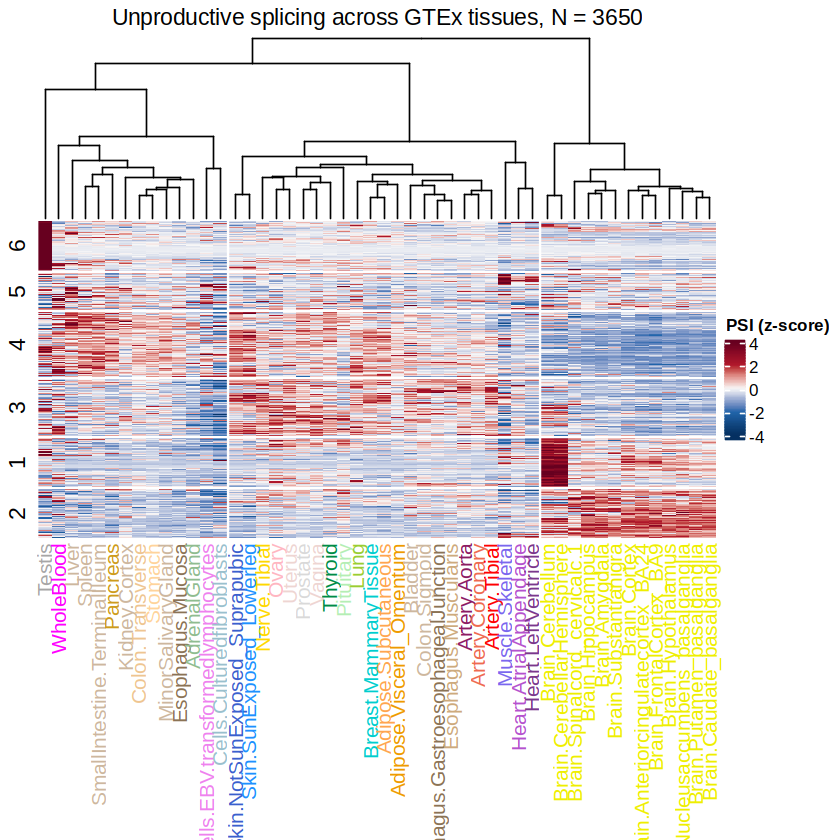

In [99]:
ht

In [113]:
library(ComplexHeatmap)
library(glue)
library(dplyr)

# Define column colors
column_colors <- setNames(
  sapply(colnames(X), function(tissue) paste0("#", gtex_colors[[tissue]]$tissue_color_hex)),
  colnames(X)
)

# Create a heatmap annotation
column_ha <- HeatmapAnnotation(
  Tissue = colnames(X),
  col = list(Tissue = column_colors),
  show_legend = FALSE  # Hide legend if unnecessary
)

# Create the heatmap
set.seed(123)
ht <- X %>%
  as.matrix() %>% 
  t() %>% 
  scale() %>% 
  t() %>% 
  Heatmap(
    column_title = glue("Unproductive splicing across GTEx tissues, N = {nrow(X)}"),
    col = colfunc,  # Example color function
    row_km = 6, row_gap = unit(0.5, "mm"), 
    column_km = 3, column_gap = unit(0.5, "mm"),
    show_parent_dend_line = FALSE,
    show_row_names = FALSE, clustering_method_rows = "complete", show_row_dend = FALSE,
    clustering_method_columns = "complete", column_dend_height = unit(1.5, "in"), show_column_dend = TRUE,
    heatmap_legend_param = list(title = "PSI (z-score)"),
    use_raster = TRUE, raster_quality = 2,
    bottom_annotation = column_ha,
      width = unit(15, "cm"),  # Adjust width
    height = unit(12, "cm"),
  )

# Draw the heatmap
pdf("heatmap_output.pdf", width = 12, height = 15)  
draw(ht)  
dev.off()

'magick' package is suggested to install to give better rasterization.

Set `ht_opt$message = FALSE` to turn off this message.



pdf 
  2

In [120]:
row_clusters <- row_order(ht)

# Convert list to a data frame for easy interpretation
cluster_df <- do.call(rbind, lapply(seq_along(row_clusters), function(i) {
  data.frame(intron = rownames(X)[row_clusters[[i]]], Cluster = i)
}))

# View the first few rows
head(cluster_df)

Warning message:
"The heatmap has not been initialized. You might have different results
if you repeatedly execute this function, e.g. when row_km/column_km was
set. It is more suggested to do as `ht = draw(ht); row_order(ht)`."


,intron,Cluster
,<chr>,<int>
1,chr14:61078927:61083549:clu_31358_+,1
2,chr4:987949:989230:clu_10969_+,1
3,chrX:11144248:11148629:clu_47291_-,1
4,chr8:123256171:123257032:clu_21033_-,1
5,chr8:123257217:123267272:clu_21033_-,1
6,chr5:32380172:32383760:clu_14090_-,1


In [123]:
up_psi_filter <- up_psi %>% filter(intron %in% cluster_df$intron)
up_psi_filter <- merge(up_psi_filter, cluster_df, by = c("intron"))
up_psi_filter %>% write_tsv(., 'UP_clusters.tsv')

In [87]:
gtex_colors <- list(
  "Adipose.Subcutaneous" = list(
    "tissue_abbrv" = "ADPSBQ", 
    "tissue_color_hex" = "FFA54F", 
    "tissue_color_rgb" = "255,165,79"
  ), 
  "Adipose.Visceral_Omentum" = list(
    "tissue_abbrv" = "ADPVSC", 
    "tissue_color_hex" = "EE9A00", 
    "tissue_color_rgb" = "238,154,0"
  ), 
  "AdrenalGland" = list(
    "tissue_abbrv" = "ADRNLG", 
    "tissue_color_hex" = "8FBC8F", 
    "tissue_color_rgb" = "143,188,143"
  ), 
  "Artery.Aorta" = list(
    "tissue_abbrv" = "ARTAORT", 
    "tissue_color_hex" = "8B1C62", 
    "tissue_color_rgb" = "139,28,98"
  ), 
  "Artery.Coronary" = list(
    "tissue_abbrv" = "ARTCRN", 
    "tissue_color_hex" = "EE6A50", 
    "tissue_color_rgb" = "238,106,80"
  ), 
  "Artery.Femoral" = list(
    "tissue_abbrv" = "ARTFMR", 
    "tissue_color_hex" = "FF4500", 
    "tissue_color_rgb" = "255,69,0"
  ), 
  "Artery.Tibial" = list(
    "tissue_abbrv" = "ARTTBL", 
    "tissue_color_hex" = "FF0000", 
    "tissue_color_rgb" = "255,0,0"
  ), 
  "Bladder" = list(
    "tissue_abbrv" = "BLDDER", 
    "tissue_color_hex" = "CDB79E", 
    "tissue_color_rgb" = "205,183,158"
  ), 
  "Brain.Amygdala" = list(
    "tissue_abbrv" = "BRNAMY", 
    "tissue_color_hex" = "EEEE00", 
    "tissue_color_rgb" = "238,238,0"
  ), 
  "Brain.Anteriorcingulatecortex_BA24" = list(
    "tissue_abbrv" = "BRNACC", 
    "tissue_color_hex" = "EEEE00", 
    "tissue_color_rgb" = "238,238,0"
  ), 
  "Brain.Caudate_basalganglia" = list(
    "tissue_abbrv" = "BRNCDT", 
    "tissue_color_hex" = "EEEE00", 
    "tissue_color_rgb" = "238,238,0"
  ), 
  "Brain.CerebellarHemisphere" = list(
    "tissue_abbrv" = "BRNCHB", 
    "tissue_color_hex" = "EEEE00", 
    "tissue_color_rgb" = "238,238,0"
  ), 
  "Brain.Cerebellum" = list(
    "tissue_abbrv" = "BRNCHA", 
    "tissue_color_hex" = "EEEE00", 
    "tissue_color_rgb" = "238,238,0"
  ), 
  "Brain.Cortex" = list(
    "tissue_abbrv" = "BRNCTXA", 
    "tissue_color_hex" = "EEEE00", 
    "tissue_color_rgb" = "238,238,0"
  ), 
  "Brain.FrontalCortex_BA9" = list(
    "tissue_abbrv" = "BRNCTXB", 
    "tissue_color_hex" = "EEEE00", 
    "tissue_color_rgb" = "238,238,0"
  ), 
  "Brain.Hippocampus" = list(
    "tissue_abbrv" = "BRNHPP", 
    "tissue_color_hex" = "EEEE00", 
    "tissue_color_rgb" = "238,238,0"
  ), 
  "Brain.Hypothalamus" = list(
    "tissue_abbrv" = "BRNHPT", 
    "tissue_color_hex" = "EEEE00", 
    "tissue_color_rgb" = "238,238,0"
  ), 
  "Brain.Nucleusaccumbens_basalganglia" = list(
    "tissue_abbrv" = "BRNNCC", 
    "tissue_color_hex" = "EEEE00", 
    "tissue_color_rgb" = "238,238,0"
  ), 
  "Brain.Putamen_basalganglia" = list(
    "tissue_abbrv" = "BRNPTM", 
    "tissue_color_hex" = "EEEE00", 
    "tissue_color_rgb" = "238,238,0"
  ), 
  "Brain.Spinalcord_cervicalc.1" = list(
    "tissue_abbrv" = "BRNSPC", 
    "tissue_color_hex" = "EEEE00", 
    "tissue_color_rgb" = "238,238,0"
  ), 
  "Brain.Substantianigra" = list(
    "tissue_abbrv" = "BRNSNG", 
    "tissue_color_hex" = "EEEE00", 
    "tissue_color_rgb" = "238,238,0"
  ), 
  "Breast.MammaryTissue" = list(
    "tissue_abbrv" = "BREAST", 
    "tissue_color_hex" = "00CDCD", 
    "tissue_color_rgb" = "0,205,205"
  ), 
  "Cells.EBV.transformedlymphocytes" = list(
    "tissue_abbrv" = "LCL", 
    "tissue_color_hex" = "EE82EE", 
    "tissue_color_rgb" = "238,130,238"
  ), 
  "Cells.Culturedfibroblasts" = list(
    "tissue_abbrv" = "FIBRBLS", 
    "tissue_color_hex" = "9AC0CD", 
    "tissue_color_rgb" = "154,192,205"
  ), 
  "Cervix.Ectocervix" = list(
    "tissue_abbrv" = "CVXECT", 
    "tissue_color_hex" = "EED5D2", 
    "tissue_color_rgb" = "238,213,210"
  ), 
  "Cervix.Endocervix" = list(
    "tissue_abbrv" = "CVSEND", 
    "tissue_color_hex" = "EED5D2", 
    "tissue_color_rgb" = "238,213,210"
  ), 
  "Colon.Sigmoid" = list(
    "tissue_abbrv" = "CLNSGM", 
    "tissue_color_hex" = "CDB79E", 
    "tissue_color_rgb" = "205,183,158"
  ), 
  "Colon.Transverse" = list(
    "tissue_abbrv" = "CLNTRN", 
    "tissue_color_hex" = "EEC591", 
    "tissue_color_rgb" = "238,197,145"
  ), 
  "Esophagus.GastroesophagealJunction" = list(
    "tissue_abbrv" = "ESPGEJ", 
    "tissue_color_hex" = "8B7355", 
    "tissue_color_rgb" = "139,115,85"
  ), 
  "Esophagus.Mucosa" = list(
    "tissue_abbrv" = "ESPMCS", 
    "tissue_color_hex" = "8B7355", 
    "tissue_color_rgb" = "139,115,85"
  ), 
  "Esophagus.Muscularis" = list(
    "tissue_abbrv" = "ESPMSL", 
    "tissue_color_hex" = "CDAA7D", 
    "tissue_color_rgb" = "205,170,125"
  ), 
  "FallopianTube" = list(
    "tissue_abbrv" = "FLLPNT", 
    "tissue_color_hex" = "EED5D2", 
    "tissue_color_rgb" = "238,213,210"
  ), 
  "Heart.AtrialAppendage" = list(
    "tissue_abbrv" = "HRTAA", 
    "tissue_color_hex" = "B452CD", 
    "tissue_color_rgb" = "180,82,205"
  ), 
  "Heart.LeftVentricle" = list(
    "tissue_abbrv" = "HRTLV", 
    "tissue_color_hex" = "7A378B", 
    "tissue_color_rgb" = "122,55,139"
  ), 
  "Kidney.Cortex" = list(
    "tissue_abbrv" = "KDNCTX", 
    "tissue_color_hex" = "CDB79E", 
    "tissue_color_rgb" = "205,183,158"
  ), 
  "Kidney.Medulla" = list(
    "tissue_abbrv" = "KDNMDL", 
    "tissue_color_hex" = "CDB79E", 
    "tissue_color_rgb" = "205,183,158"
  ), 
  "Liver" = list(
    "tissue_abbrv" = "LIVER", 
    "tissue_color_hex" = "CDB79E", 
    "tissue_color_rgb" = "205,183,158"
  ), 
  "Lung" = list(
    "tissue_abbrv" = "LUNG", 
    "tissue_color_hex" = "9ACD32", 
    "tissue_color_rgb" = "154,205,50"
  ), 
  "MinorSalivaryGland" = list(
    "tissue_abbrv" = "SLVRYG", 
    "tissue_color_hex" = "CDB79E", 
    "tissue_color_rgb" = "205,183,158"
  ), 
  "Muscle.Skeletal" = list(
    "tissue_abbrv" = "MSCLSK", 
    "tissue_color_hex" = "7A67EE", 
    "tissue_color_rgb" = "122,103,238"
  ), 
  "Nerve.Tibial" = list(
    "tissue_abbrv" = "NERVET", 
    "tissue_color_hex" = "FFD700", 
    "tissue_color_rgb" = "255,215,0"
  ), 
  "Ovary" = list(
    "tissue_abbrv" = "OVARY", 
    "tissue_color_hex" = "FFB6C1", 
    "tissue_color_rgb" = "255,182,193"
  ), 
  "Pancreas" = list(
    "tissue_abbrv" = "PNCREAS", 
    "tissue_color_hex" = "CD9B1D", 
    "tissue_color_rgb" = "205,155,29"
  ), 
  "Pituitary" = list(
    "tissue_abbrv" = "PTTARY", 
    "tissue_color_hex" = "B4EEB4", 
    "tissue_color_rgb" = "180,238,180"
  ), 
  "Prostate" = list(
    "tissue_abbrv" = "PRSTTE", 
    "tissue_color_hex" = "D9D9D9", 
    "tissue_color_rgb" = "217,217,217"
  ), 
  "Skin.NotSunExposed_Suprapubic" = list(
    "tissue_abbrv" = "SKINNS", 
    "tissue_color_hex" = "3A5FCD", 
    "tissue_color_rgb" = "58,95,205"
  ), 
  "Skin.SunExposed_Lowerleg" = list(
    "tissue_abbrv" = "SKINS", 
    "tissue_color_hex" = "1E90FF", 
    "tissue_color_rgb" = "30,144,255"
  ), 
  "SmallIntestine.TerminalIleum" = list(
    "tissue_abbrv" = "SNTTRM", 
    "tissue_color_hex" = "CDB79E", 
    "tissue_color_rgb" = "205,183,158"
  ), 
  "Spleen" = list(
    "tissue_abbrv" = "SPLEEN", 
    "tissue_color_hex" = "CDB79E", 
    "tissue_color_rgb" = "205,183,158"
  ), 
  "Stomach" = list(
    "tissue_abbrv" = "STMACH", 
    "tissue_color_hex" = "FFD39B", 
    "tissue_color_rgb" = "255,211,155"
  ), 
  "Testis" = list(
    "tissue_abbrv" = "TESTIS", 
    "tissue_color_hex" = "A6A6A6", 
    "tissue_color_rgb" = "166,166,166"
  ), 
  "Thyroid" = list(
    "tissue_abbrv" = "THYROID", 
    "tissue_color_hex" = "008B45", 
    "tissue_color_rgb" = "0,139,69"
  ), 
  "Uterus" = list(
    "tissue_abbrv" = "UTERUS", 
    "tissue_color_hex" = "EED5D2", 
    "tissue_color_rgb" = "238,213,210"
  ), 
  "Vagina" = list(
    "tissue_abbrv" = "VAGINA", 
    "tissue_color_hex" = "EED5D2", 
    "tissue_color_rgb" = "238,213,210"
  ), 
  "WholeBlood" = list(
    "tissue_abbrv" = "WHLBLD", 
    "tissue_color_hex" = "FF00FF", 
    "tissue_color_rgb" = "255,0,255"
  )
)

In [81]:
X

,Artery.Aorta,Brain.Cortex,Brain.Nucleusaccumbens_basalganglia,Esophagus.Muscularis,Adipose.Visceral_Omentum,AdrenalGland,Artery.Coronary,Bladder,Brain.Amygdala,Brain.Anteriorcingulatecortex_BA24,⋯,Breast.MammaryTissue,Cells.EBV.transformedlymphocytes,Colon.Sigmoid,Colon.Transverse,Liver,Muscle.Skeletal,Nerve.Tibial,Skin.NotSunExposed_Suprapubic,Skin.SunExposed_Lowerleg,WholeBlood
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,0.0830389521,0.2407215680,0.157674975,8.753754e-02,0.0817457972,0.0390286804,1.078209e-01,1.123610e-01,0.1533244101,0.1576481556,⋯,0.1285137126,2.517681e-02,0.119784245,6.349370e-02,0.0306761548,0.2097740673,0.2089986449,0.1588684396,0.1658607010,0.042327018
2,0.0187991722,0.0139744120,0.010514751,1.581324e-02,0.0131517192,0.0087858354,1.706494e-02,1.487181e-02,0.0070337334,0.0149683292,⋯,0.0156789925,1.074553e-02,0.013978630,1.571402e-02,0.0097862207,0.0076548343,0.0147767594,0.0175186627,0.0105282523,0.019714040
3,0.2903566590,0.2475714295,0.240875122,2.417582e-01,0.2519950591,0.2250830481,2.518879e-01,2.057754e-01,0.2336802285,0.2070391569,⋯,0.2742707380,1.805201e-01,0.211172139,1.859468e-01,0.2087604874,0.1129350324,0.3015598773,0.2450514150,0.2907946237,0.174686816
4,0.2925359714,0.1932268198,0.216121672,3.333732e-01,0.3109713445,0.2645810989,3.212605e-01,3.330570e-01,0.2203847746,0.1855458576,⋯,0.2985399353,2.496546e-01,0.340211933,3.210916e-01,0.3289088184,0.2351715535,0.3016240295,0.2774421686,0.2732430602,0.308342210
5,0.0198316885,0.0121058777,0.011414277,2.377158e-02,0.0289272968,0.0166842274,2.344295e-02,1.898552e-02,0.0093393837,0.0030634849,⋯,0.0257052995,2.256364e-02,0.025307736,2.808938e-02,0.0266000721,0.0111821535,0.0200733426,0.0257666916,0.0226865145,0.051886185
6,0.3497426399,0.2080576272,0.236789969,3.657433e-01,0.3130473393,0.2760698203,3.460934e-01,3.842562e-01,0.2466977384,0.2128421836,⋯,0.3100004731,2.806946e-01,0.366285839,3.487636e-01,0.3487910640,0.2634408385,0.3216138856,0.2942987940,0.2883121341,0.306227447
7,0.0209077756,0.0109099374,0.009736987,2.159134e-02,0.0244459336,0.0159135194,2.135289e-02,1.592270e-02,0.0154190154,0.0033987323,⋯,0.0282476053,2.172668e-02,0.021838522,2.633038e-02,0.0239713447,0.0089320810,0.0194965340,0.0198853539,0.0267613337,0.048971140
8,0.0009771331,0.1206386417,0.048819340,3.295422e-04,0.0010148969,0.0060018594,9.180308e-04,1.528974e-03,0.0208581362,0.0715637230,⋯,0.0010270954,2.806301e-06,0.001713852,1.777032e-03,0.0029534724,0.0023957350,0.0023793146,0.0022060527,0.0011308290,0.002844602
9,0.1158654221,0.1143893229,0.056903583,1.435922e-01,0.0732695985,0.0820288252,9.998103e-02,1.226689e-01,0.0429098473,0.0494935974,⋯,0.0556920031,6.986361e-02,0.131731177,1.025500e-01,0.1060005719,0.1089996422,0.0433625046,0.0585394166,0.0506273475,0.055715642
